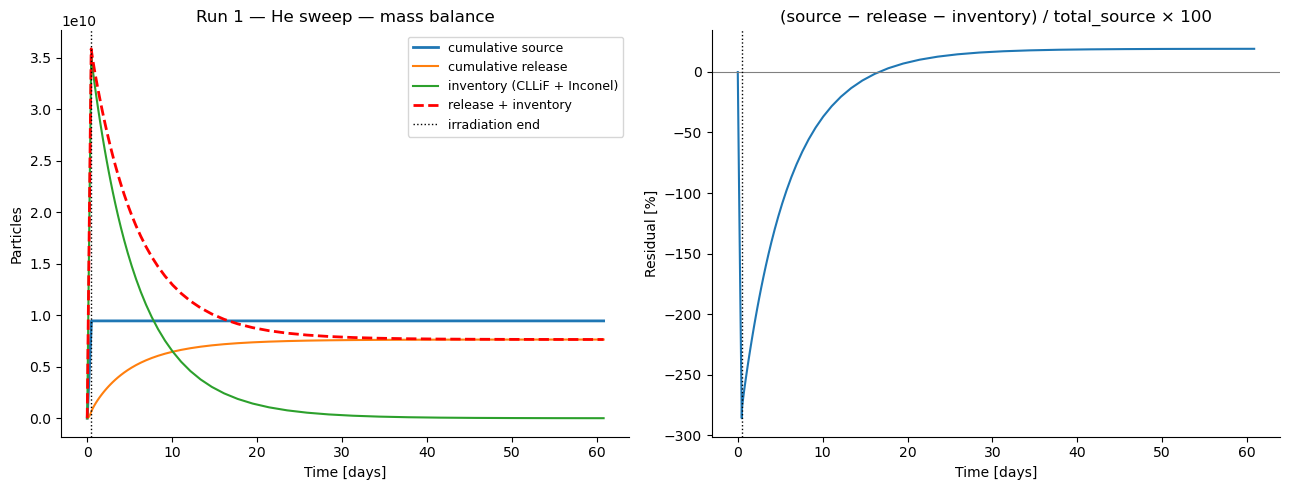


=== Run 1 / He mass balance summary ===
  irradiation_time          = 43200.00 s (0.50 d)
  source rate               = 2.188e+05 particles/s
  total source (analytical) = 9.450e+09 particles
  cum source at end of run  = 9.450e+09 particles
  cum release at end        = 7.641e+09 particles
  inventory at end          = 4.930e+06 particles
  release + inv at end      = 7.646e+09 particles
  residual at end           = 1.804e+09 (19.09%)
  max |residual|            = 2.702e+10 (285.91%)
  inventory peak            = 3.524e+10
  inventory peak / source   = 3.729


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import requests
from libra_toolbox.tritium.model import ureg

# ---- Replicate the exact source as build_model uses ----
RUN_URLS = {
    1: "https://raw.githubusercontent.com/LIBRA-project/BABY-1L-run-1/refs/tags/v0.6/data/processed_data.json",
    2: "https://raw.githubusercontent.com/LIBRA-project/BABY-1L-run-2/refs/tags/v0.5/data/processed_data.json",
    3: "https://raw.githubusercontent.com/LIBRA-project/BABY-1L-run-3/refs/tags/v0.2/data/processed_data.json",
    4: "https://raw.githubusercontent.com/LIBRA-project/BABY-1L-run-4/refs/tags/v0.1/data/processed_data.json",
}
TRITIUM_PRODUCTION = {1: 9.45e9, 2: 5.36e10, 3: 1.66e10, 4: 1.81e10}
V_CLLIF = 1.0e-3


def get_total_irradiation_time(run_id: int) -> float:
    data = requests.get(RUN_URLS[run_id]).json()
    duration = 0
    for irr in data["irradiations"]:
        start = irr["start_time"]["value"] * ureg(irr["start_time"]["unit"])
        end = irr["stop_time"]["value"] * ureg(irr["stop_time"]["unit"])
        duration += (end - start).to(ureg("s")).magnitude
    return duration


def load_csv(path):
    df = pd.read_csv(path)
    return df.iloc[:, 0].values, df.iloc[:, 1].values


# ============================================================
# Mass-balance diagnostic for one run/sweep
# ============================================================
def mass_balance_check(run_id, sweep_gas="He", base="results/baby_2d"):
    folder = f"{base}/run_{run_id}/sweep_{sweep_gas}"

    irradiation_time = get_total_irradiation_time(run_id)
    source_strength = TRITIUM_PRODUCTION[run_id] / (irradiation_time * V_CLLIF)
    # This is exactly what build_model uses:
    #   ParticleSource(value=tritium_source, volume=vol_cllif, ...)
    # which means rate = source_strength [particles/m^3/s] * V_CLLIF [m^3]
    #                  = TRITIUM_PRODUCTION[run_id] / irradiation_time
    # for t < irradiation_time, and 0 afterwards.
    rate = TRITIUM_PRODUCTION[run_id] / irradiation_time  # [particles/s]

    # ---- Surface fluxes ----
    t, j_ls = load_csv(f"{folder}/flux_liquid_surface.csv")
    _, j_gs = load_csv(f"{folder}/flux_gap_sidewall.csv")
    _, j_tc = load_csv(f"{folder}/flux_inconel_top_cap.csv")
    j_total = j_ls + j_gs + j_tc

    # ---- Inventories ----
    df_cl = pd.read_csv(f"{folder}/inventory_cllif.csv")
    df_in = pd.read_csv(f"{folder}/inventory_inconel.csv")
    t_inv = df_cl.iloc[:, 0].values
    inv_total = df_cl.iloc[:, 1].values + df_in.iloc[:, 1].values

    # ---- Cumulative source built from the EXACT model source ----
    # Use the flux time grid so we can compare on common axis.
    # Source rate is a step function: rate for t < t_irr, 0 after.
    cum_source = np.where(
        t < irradiation_time,
        rate * t,                          # ramping up
        rate * irradiation_time,           # plateau at total = TRITIUM_PRODUCTION
    )

    # ---- Cumulative release on flux grid ----
    cum_release = cumulative_trapezoid(j_total, x=t, initial=0)

    # ---- Inventory interpolated to flux grid ----
    inv_interp = np.interp(t, t_inv, inv_total)

    # ---- Residual ----
    residual = cum_source - cum_release - inv_interp
    residual_pct = residual / TRITIUM_PRODUCTION[run_id] * 100

    # ============================================================
    # Plot
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # (1) Mass balance components
    ax = axes[0]
    ax.plot(t / 86400, cum_source, label="cumulative source", lw=2)
    ax.plot(t / 86400, cum_release, label="cumulative release")
    ax.plot(t / 86400, inv_interp, label="inventory (CLLiF + Inconel)")
    ax.plot(
        t / 86400,
        cum_release + inv_interp,
        label="release + inventory",
        ls="--",
        lw=2,
        color="red",
    )
    ax.axvline(
        irradiation_time / 86400, color="k", ls=":", lw=1, label="irradiation end"
    )
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Particles")
    ax.set_title(f"Run {run_id} — {sweep_gas} sweep — mass balance")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # (2) Residual
    ax = axes[1]
    ax.plot(t / 86400, residual_pct)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(irradiation_time / 86400, color="k", ls=":", lw=1)
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Residual [%]")
    ax.set_title("(source − release − inventory) / total_source × 100")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ---- Print summary ----
    print(f"\n=== Run {run_id} / {sweep_gas} mass balance summary ===")
    print(f"  irradiation_time          = {irradiation_time:.2f} s ({irradiation_time/86400:.2f} d)")
    print(f"  source rate               = {rate:.3e} particles/s")
    print(f"  total source (analytical) = {TRITIUM_PRODUCTION[run_id]:.3e} particles")
    print(f"  cum source at end of run  = {cum_source[-1]:.3e} particles")
    print(f"  cum release at end        = {cum_release[-1]:.3e} particles")
    print(f"  inventory at end          = {inv_interp[-1]:.3e} particles")
    print(f"  release + inv at end      = {cum_release[-1] + inv_interp[-1]:.3e} particles")
    print(f"  residual at end           = {residual[-1]:.3e} ({residual_pct[-1]:.2f}%)")
    print(f"  max |residual|            = {np.abs(residual).max():.3e} ({np.abs(residual_pct).max():.2f}%)")
    print(f"  inventory peak            = {inv_interp.max():.3e}")
    print(f"  inventory peak / source   = {inv_interp.max() / TRITIUM_PRODUCTION[run_id]:.3f}")


if __name__ == "__main__":
    mass_balance_check(run_id=1, sweep_gas="He")
    # mass_balance_check(run_id=2, sweep_gas="He")